## Setup

### Import modules

In [60]:
%pip install seaborn

2447.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [61]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error

### Preprocessing

In [62]:
raw_name = "data.csv"
daily_name = "daily.csv"
weekly_name = "weekly.csv"
monthly_name ="monthly.csv"
results_name = "results.csv"
load_chunksize = 1_000_000

### Models

In [63]:
ts_splits = 5

hyperparams = {
    'adaboost': {
        'n_estimators':[100,300,500,800,1500],
        'learning_rate':[0.01,0.03,0.05,0.08],
    },
    'xgboost': {
        'n_estimators':[100,300,500,800,1500],
        'learning_rate':[0.01,0.03,0.05,0.08],
        'max_depth':[2,3,5,8],
        'subsample':[0.6,0.8,1],
        'gamma':[0,0.1,0.25,0.5]
    }
}

sample_size = 25

### Auxiliary values

In [64]:
def add_lag_features(df, target_col, lags):
    df = df.sort_values("date").copy()
    
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    
    return df

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

try:
    results = pd.read_csv(results_name)
    need_results = False
except:
    need_results = True

print('Setup complete!')

Setup complete!


## Preprocessing

### Daily aggregation

In [65]:
if need_results:
    try:
        daily = pd.read_csv(daily_name)
        print('Daily aggregation loaded!')
    except:
        results = []

        for chunk in pd.read_csv(raw_name, chunksize=load_chunksize):

            chunk = chunk.dropna(subset=["onpromotion"])
            chunk["onpromotion"] = chunk["onpromotion"].astype(int)

            # weighted promotion = sales * promotion
            chunk["promo_weight"] = chunk["unit_sales"] * chunk["onpromotion"]

            grouped = chunk.groupby("date").agg(
                sales=("unit_sales", "sum"),
                promo_weight=("promo_weight", "sum")
            ).reset_index()

            results.append(grouped)

        print('Dataset loaded!')

        daily = pd.concat(results)
        # aggregate across chunks
        daily = daily.groupby("date").agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()
        daily["promotion"] = daily["promo_weight"] / daily["sales"].replace(0, pd.NA)

        daily = daily[["date", "sales", "promotion"]]
        daily["date"] = pd.to_datetime(daily["date"])
        daily["day_of_week"] = daily["date"].dt.dayofweek
        daily["month"] = daily["date"].dt.month
        daily["year"] = daily["date"].dt.year

        daily = add_lag_features(
            daily,
            target_col="sales",
            lags=[1, 7, 14, 28]
        )
        daily = daily.dropna()

        daily.to_csv(daily_name, index=False)
        print('Daily aggregation saved!')

### Weekly aggregation

In [66]:
if need_results:
    try:
        weekly = pd.read_csv(weekly_name)
        print('Weekly aggregation loaded!')
    except:
        weekly = daily.copy()

        # Reconstruct promo_weight to avoid averaging ratios
        weekly["promo_weight"] = weekly["promotion"] * weekly["sales"]

        weekly = weekly.groupby(pd.Grouper(key="date", freq="W")).agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()

        weekly["promotion"] = weekly["promo_weight"] / weekly["sales"]

        weekly = weekly[["date", "sales", "promotion"]]
        weekly["month"] = weekly["date"].dt.month
        weekly["year"] = weekly["date"].dt.year

        weekly = add_lag_features(
            weekly,
            target_col="sales",
            lags=[1, 2, 4, 8]
        )
        weekly = weekly.dropna()

        weekly.to_csv(weekly_name, index=False)
        print('Weekly aggregation saved!')

### Monthly aggregation

In [67]:
if need_results:
    try:
        monthly = pd.read_csv(monthly_name)
        print('Monthly aggregation loaded!')
    except:
        monthly = daily.copy()

        monthly["promo_weight"] = monthly["promotion"] * monthly["sales"]

        monthly = monthly.groupby(pd.Grouper(key="date", freq="ME")).agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()

        monthly["promotion"] = monthly["promo_weight"] / monthly["sales"]

        monthly = monthly[["date", "sales", "promotion"]]
        monthly["month"] = monthly["date"].dt.month
        monthly["year"] = monthly["date"].dt.year

        monthly = add_lag_features(
            monthly,
            target_col="sales",
            lags=[1, 2, 3, 6]
        )
        monthly = monthly.dropna()

        monthly.to_csv(monthly_name, index=False)
        print('Monthly aggregation saved!')

        print('Data ready!')

### Models

### Data setup

In [68]:
if need_results:
    daily_split_id = int(len(daily) * 0.8)
    daily_train = daily.iloc[:daily_split_id]
    daily_test  = daily.iloc[daily_split_id:]
    weekly_split_id = int(len(weekly) * 0.8)
    weekly_train = weekly.iloc[:weekly_split_id]
    weekly_test  = weekly.iloc[weekly_split_id:]
    monthly_split_id = int(len(monthly) * 0.8)
    monthly_train = monthly.iloc[:monthly_split_id]
    monthly_test  = monthly.iloc[monthly_split_id:]
    train = {
        'daily': daily_train,
        'weekly': weekly_train,
        'monthly': monthly_train
    }
    test = {
        'daily': daily_test,
        'weekly': weekly_test,
        'monthly': monthly_test
    }

### Parameter tuning

In [69]:
if need_results:
    best_models = []

    # time-series cross validation
    tscv = TimeSeriesSplit(n_splits=ts_splits)

    for dataset_name, df in train.items():

        print(f"\n===== Processing {dataset_name} dataset =====")

        # features and target
        X = df.drop(columns=['date', 'sales'])
        y = df['sales']

        # -----------------------------
        # AdaBoost
        # -----------------------------
        print(f"Running AdaBoost GridSearchCV for {dataset_name}...")

        ada_model = AdaBoostRegressor()

        ada_search = GridSearchCV(
            estimator=ada_model,
            param_grid=hyperparams['adaboost'],
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            verbose=1
        )

        ada_search.fit(X, y)

        best_ada = ada_search.best_estimator_

        best_models.append({
            'dataset': dataset_name,
            'model_name': 'AdaBoost',
            'best_model': best_ada,
            'best_params': ada_search.best_params_,
            'best_score': -ada_search.best_score_
        })

        print("Best AdaBoost params:", ada_search.best_params_)
        print("Best AdaBoost MAE:", -ada_search.best_score_)

        # -----------------------------
        # XGBoost
        # -----------------------------
        print(f"\nRunning XGBoost GridSearchCV for {dataset_name}...")

        xgb_model = XGBRegressor(objective='reg:squarederror')

        xgb_search = GridSearchCV(
            estimator=xgb_model,
            param_grid=hyperparams['xgboost'],
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            verbose=1
        )

        xgb_search.fit(X, y)

        best_xgb = xgb_search.best_estimator_

        best_models.append({
            'dataset': dataset_name,
            'model_name': 'XGBoost',
            'best_model': best_xgb,
            'best_params': xgb_search.best_params_,
            'best_score': -xgb_search.best_score_
        })

        print("Best XGBoost params:", xgb_search.best_params_)
        print("Best XGBoost MAE:", -xgb_search.best_score_)

    print("\nHyperparameter tuning complete!")
    print(f"Stored {len(best_models)} best models.")

### Training and evaluation

In [70]:
if need_results:
    tscv = TimeSeriesSplit(n_splits=sample_size)

    results = []

    for model_info in best_models:
        dataset_name = model_info['dataset']
        model_name = model_info['model_name']
        model = model_info['best_model']

        data = train[dataset_name]
        X = data.drop(columns=['date', 'sales'])
        y = data['sales']

        rmse_scores = []
        mae_scores = []
        mape_scores = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            mae = mean_absolute_error(y_val, y_pred)
            mape = mean_absolute_percentage_error(y_val, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            mape_scores.append(mape)

        results.append({
            'dataset': dataset_name,
            'model_name': model_name,
            'rmse_scores': rmse_scores,
            'mae_scores': mae_scores,
            'mape_scores': mape_scores,
            'rmse_mean': np.mean(rmse_scores),
            'mae_mean': np.mean(mae_scores),
            'mape_mean': np.mean(mape_scores),
            'rmse_std': np.std(rmse_scores),
            'mae_std': np.std(mae_scores),
            'mape_std': np.std(mape_scores),
        })

    results = pd.DataFrame(results)
    results.to_csv(results_name)
    print('Results saved!')

### The Original Dataset & Promotion Balance

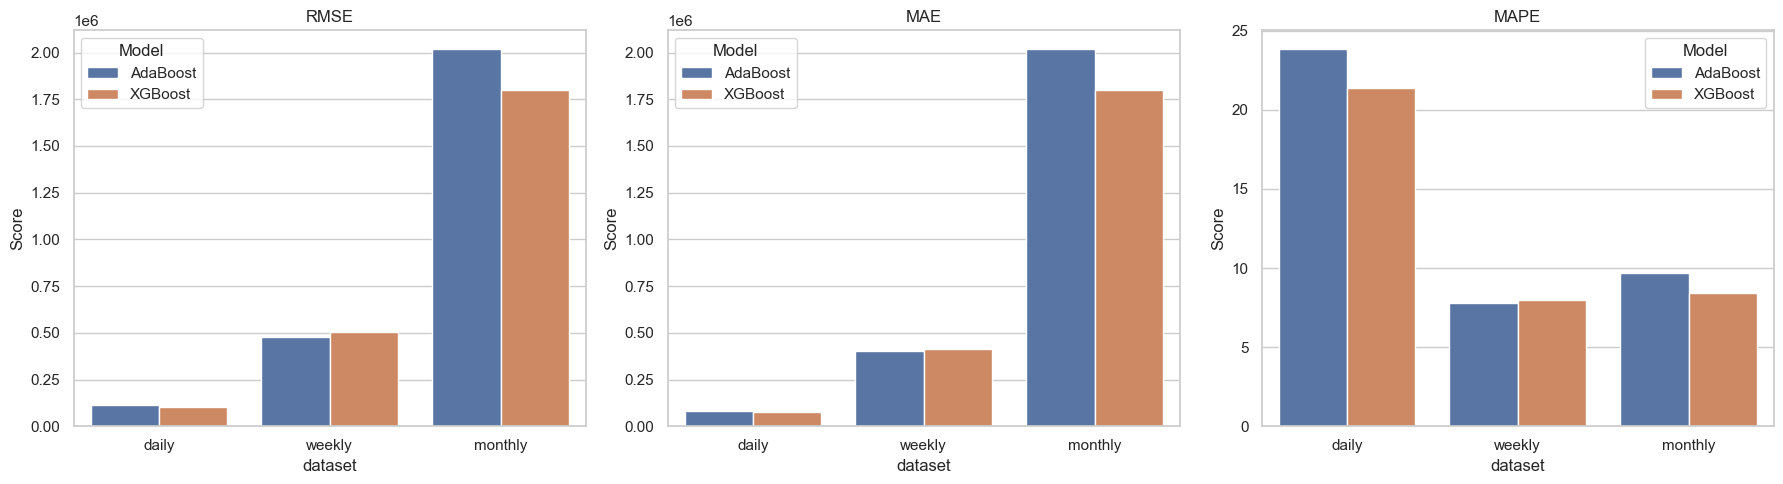

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['rmse', 'mae', 'mape']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.barplot(
        data=results,
        x='dataset',
        y=f'{metric}_mean',
        hue='model_name',
        ax=ax,
        capsize=0.1
    )
    '''
    # add error bars manually (since seaborn barplot doesn't fully expose std cleanly in all versions)
    for j, bar in enumerate(ax.patches):
        dataset_idx = j // len(results['model_name'].unique())
        model_idx = j % len(results['model_name'].unique())
    '''
        
    ax.set_title(metric.upper())
    ax.set_ylabel('Score')
    ax.legend(title='Model')

plt.tight_layout()
plt.show()

### The Original Dataset & Promotion Balance

--- 1. ORIGINAL DATASET DIAGNOSTICS ---


/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_5170/3155844134.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trimmed_sample, x='onpromotion', y='unit_sales', ax=axes1[1], palette='Set2')


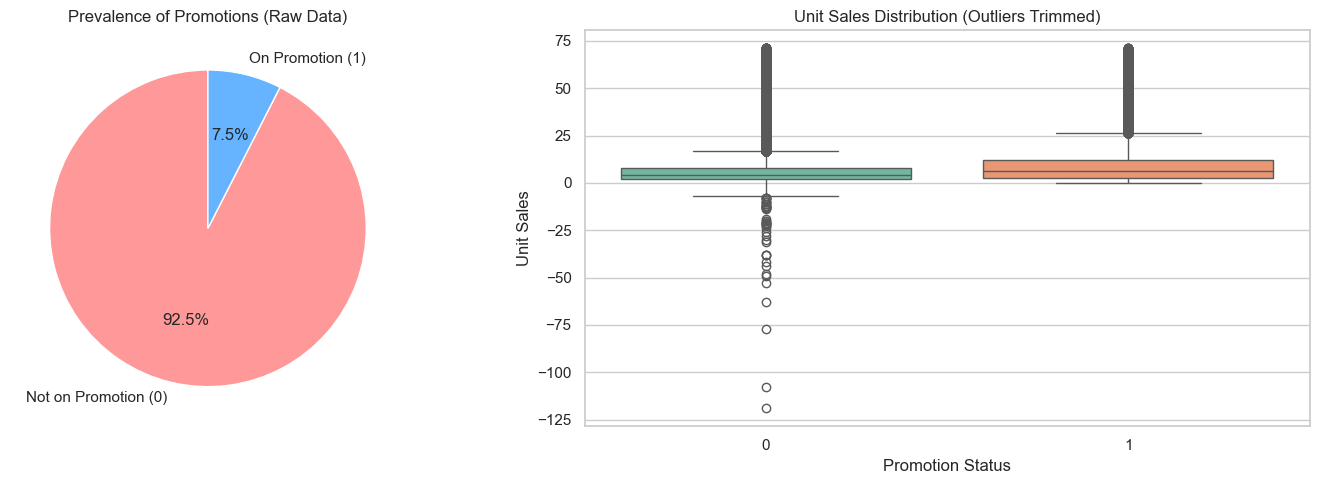


--- 2. AGGREGATED DATASETS DIAGNOSTICS ---


/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_5170/3155844134.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_agg, x='Granularity', y='sales', ax=axes2[0], palette='pastel')
/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_5170/3155844134.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_agg, x='Granularity', y='promotion', ax=axes2[1], palette='pastel')


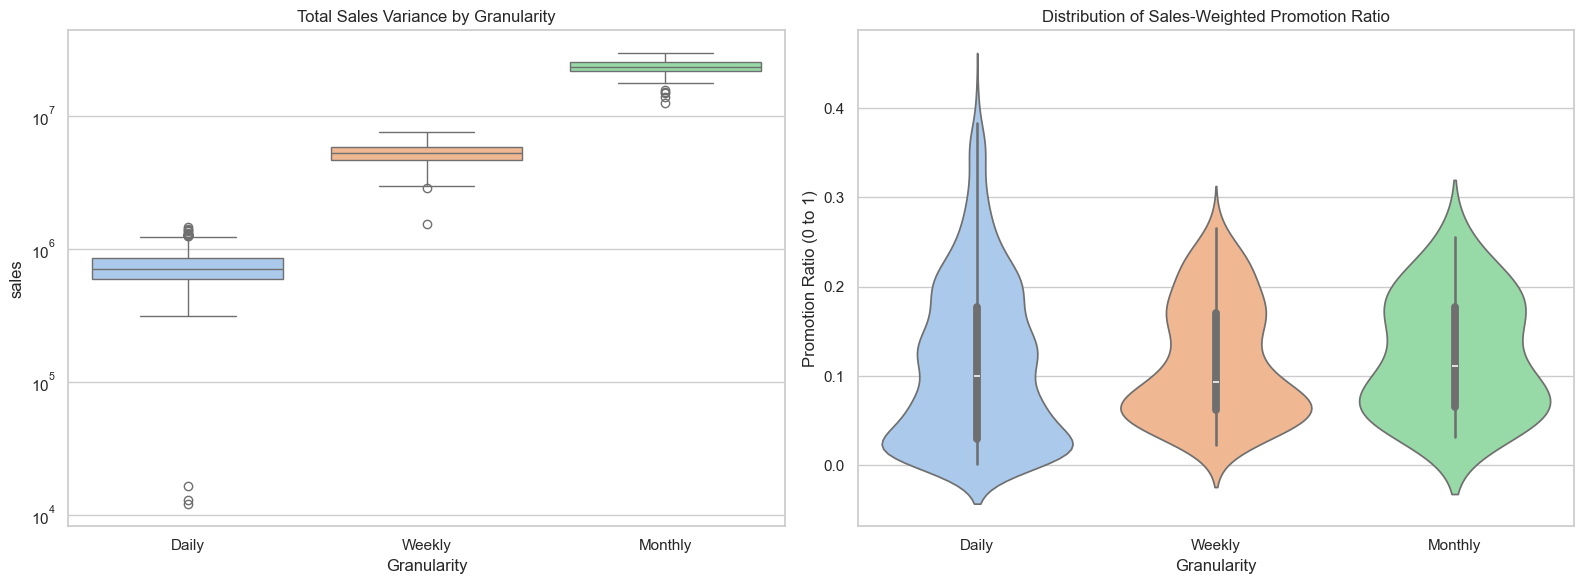


--- 3. HYPERPARAMETER TUNING DIAGNOSTICS ---
   [Note] XGBoost search object not found in memory. Skipping tuning plot.
   (Run this cell immediately after your GridSearchCV block to see this plot!)

--- 4. FINAL SCORES VARIANCE (25-Fold CV) ---


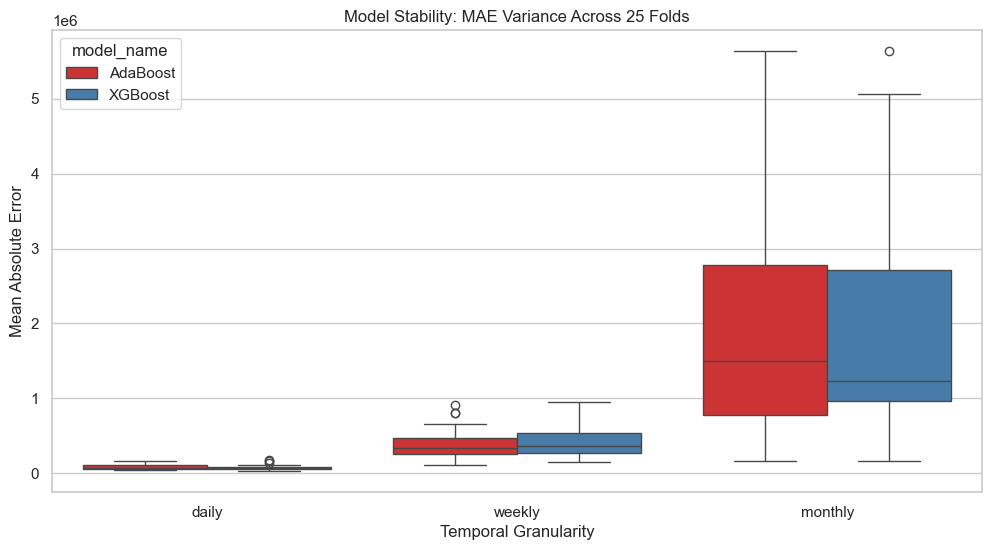

In [72]:
# %pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Set seaborn style for cleaner aesthetics
sns.set_theme(style="whitegrid")

# ==========================================
# 1. ORIGINAL DATASET DIAGNOSTICS
# ==========================================
print("--- 1. ORIGINAL DATASET DIAGNOSTICS ---")
# Using the fully cleaned dataset name. Adjust the path if it is sitting somewhere else!
raw_sample = pd.read_csv("fully_cleaned_train.csv", skiprows=lambda i: i > 0 and i % 20 != 0)
raw_sample = raw_sample.dropna(subset=['onpromotion'])
raw_sample['onpromotion'] = raw_sample['onpromotion'].astype(int)

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Promotion Imbalance
promo_counts = raw_sample['onpromotion'].value_counts()
axes1[0].pie(promo_counts, labels=['Not on Promotion (0)', 'On Promotion (1)'], 
            autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes1[0].set_title('Prevalence of Promotions (Raw Data)')

# Plot 2: Boxplot of Unit Sales (Trimmed outliers)
q_high = raw_sample['unit_sales'].quantile(0.99)
trimmed_sample = raw_sample[raw_sample['unit_sales'] < q_high]

sns.boxplot(data=trimmed_sample, x='onpromotion', y='unit_sales', ax=axes1[1], palette='Set2')
axes1[1].set_title('Unit Sales Distribution (Outliers Trimmed)')
axes1[1].set_xlabel('Promotion Status')
axes1[1].set_ylabel('Unit Sales')

plt.tight_layout()
plt.show()


# ==========================================
# 2. AGGREGATED DATASETS DIAGNOSTICS
# ==========================================
print("\n--- 2. AGGREGATED DATASETS DIAGNOSTICS ---")
daily = pd.read_csv("daily.csv")
weekly = pd.read_csv("weekly.csv")
monthly = pd.read_csv("monthly.csv")

daily['Granularity'] = 'Daily'
weekly['Granularity'] = 'Weekly'
monthly['Granularity'] = 'Monthly'
combined_agg = pd.concat([daily, weekly, monthly], ignore_index=True)

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Means and Variances of Sales
sns.boxplot(data=combined_agg, x='Granularity', y='sales', ax=axes2[0], palette='pastel')
axes2[0].set_title('Total Sales Variance by Granularity')
axes2[0].set_yscale('log') # Log scale because monthly is vastly larger

# Plot 2: Promotion Ratio distribution
sns.violinplot(data=combined_agg, x='Granularity', y='promotion', ax=axes2[1], palette='pastel')
axes2[1].set_title('Distribution of Sales-Weighted Promotion Ratio')
axes2[1].set_ylabel('Promotion Ratio (0 to 1)')

plt.tight_layout()
plt.show()


# ==========================================
# 3. HYPERPARAMETER TUNING DIAGNOSTICS
# ==========================================
print("\n--- 3. HYPERPARAMETER TUNING DIAGNOSTICS ---")

def plot_grid_search_results(grid_search_obj, param_x, param_hue, title):
    results_df = pd.DataFrame(grid_search_obj.cv_results_)
    # Convert negative MAE back to positive
    results_df['mean_test_score'] = results_df['mean_test_score'] * -1
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=results_df, x=param_x, y='mean_test_score', hue=param_hue, marker='o', palette='viridis')
    plt.title(f'Hyperparameter Tuning: {title}')
    plt.ylabel('Mean Absolute Error (Lower is Better)')
    plt.xlabel(param_x.replace('param_', ''))
    plt.legend(title=param_hue.replace('param_', ''))
    plt.show()

# Attempt to plot tuning results if the search objects are still in memory
try:
    plot_grid_search_results(xgb_search, 'param_n_estimators', 'param_learning_rate', 'XGBoost (Learning Rate vs Estimators)')
except NameError:
    print("   [Note] XGBoost search object not found in memory. Skipping tuning plot.")
    print("   (Run this cell immediately after your GridSearchCV block to see this plot!)")


# ==========================================
# 4. FINAL SCORES VARIANCE (25-Fold CV)
# ==========================================
print("\n--- 4. FINAL SCORES VARIANCE (25-Fold CV) ---")
final_results = pd.read_csv("results.csv")

# Safely convert the string representation of lists back into actual Python lists
final_results['mae_scores'] = final_results['mae_scores'].apply(ast.literal_eval)

# Explode the lists so each fold has its own row
exploded_results = final_results.explode('mae_scores')
exploded_results['mae_scores'] = exploded_results['mae_scores'].astype(float)

plt.figure(figsize=(12, 6))
sns.boxplot(data=exploded_results, x='dataset', y='mae_scores', hue='model_name', palette='Set1')
plt.title('Model Stability: MAE Variance Across 25 Folds')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Temporal Granularity')
plt.show()